# Single chain dataset

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
MLP_SINGLE_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")
MLP_CCTX_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")
DEEPSAD_SINGLE_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")
DEEPSAD_CCTX_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
mlp_single_run_dirs = sorted(
    p for p in MLP_SINGLE_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)
mlp_cctx_run_dirs = sorted(
    p for p in MLP_CCTX_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)
deepsad_single_run_dirs = sorted(
    p for p in DEEPSAD_SINGLE_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)
deepsad_cctx_run_dirs = sorted(
    p for p in DEEPSAD_CCTX_ROOT.glob("train_epochs100_augment0_lr0.002*")
    if p.is_dir() and (p / "params.yaml").exists()
)

total_run_dirs = (
    mlp_single_run_dirs + mlp_cctx_run_dirs + deepsad_single_run_dirs + deepsad_cctx_run_dirs
)

print(f"Found {len(total_run_dirs)} run directories")
for p in total_run_dirs:
    print(p)

Found 8 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171517
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608171525
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171532
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfus

## Fold training time comparison

In [3]:
import yaml
import pandas as pd

MODEL_GROUPS = [
    ("MLP", "Single", mlp_single_run_dirs),
    ("MLP", "Cross-tx", mlp_cctx_run_dirs),
    ("DeepSAD", "Single", deepsad_single_run_dirs),
    ("DeepSAD", "Cross-tx", deepsad_cctx_run_dirs),
]

def load_fold_durations(run_dir: Path) -> dict:
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    # fold_durations.csv gives total wall-clock time per fold, but early stopping
    # means folds run different numbers of epochs, so raw fold time isn't
    # apples-to-apples. Count actual epochs run per fold (non-NaN rows in the
    # per-epoch loss curve) and normalize to time per epoch.
    durations = pd.read_csv(run_dir / "fold_durations.csv").set_index("fold")["time"]
    loss_df = pd.read_csv(run_dir / "val_train_loss.csv")
    fold_cols = [c for c in loss_df.columns if c != "epoch"]
    n_epochs = loss_df[fold_cols].notna().sum()
    epoch_time = durations / n_epochs

    return {
        "run_dir": run_dir,
        "rm_semantic_fusion": doc["params"].get("rm_semantic_fusion", False),
        "n_epochs_mean": n_epochs.mean(),
        "n_epochs_std": n_epochs.std(ddof=0),
        "epoch_time_mean": epoch_time.mean(),
        "epoch_time_std": epoch_time.std(ddof=0),
    }

records = []
for arch, scope, run_dirs in MODEL_GROUPS:
    for run_dir in run_dirs:
        rec = load_fold_durations(run_dir)
        rec["arch"] = arch
        rec["scope"] = scope
        records.append(rec)

foldtime_df = pd.DataFrame(records)
foldtime_df["evaluation"] = foldtime_df["rm_semantic_fusion"].map(
    {False: "With Semantic Fusion", True: "Without Semantic Fusion"}
)
foldtime_df = foldtime_df.sort_values(["scope", "arch", "rm_semantic_fusion"]).reset_index(drop=True)
foldtime_df

,run_dir,rm_semantic_fusion,n_epochs_mean,n_epochs_std,epoch_time_mean,epoch_time_std,arch,scope,evaluation
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,False,27.8,5.306600,8.782094,0.438628,DeepSAD,Cross-tx,With Semantic Fusion
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,True,33.6,8.089499,6.554101,0.199771,DeepSAD,Cross-tx,Without Semantic Fusion
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,False,37.6,3.929377,8.690305,0.084003,MLP,Cross-tx,With Semantic Fusion
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,True,28.4,9.372300,6.258787,0.096334,MLP,Cross-tx,Without Semantic Fusion
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,False,35.4,5.238320,2.683548,0.036029,DeepSAD,Single,With Semantic Fusion
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,True,29.6,9.666437,2.477144,0.016184,DeepSAD,Single,Without Semantic Fusion
6,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,False,35.4,5.238320,2.543520,0.002336,MLP,Single,With Semantic Fusion
7,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,True,29.6,9.666437,2.367339,0.066594,MLP,Single,Without Semantic Fusion


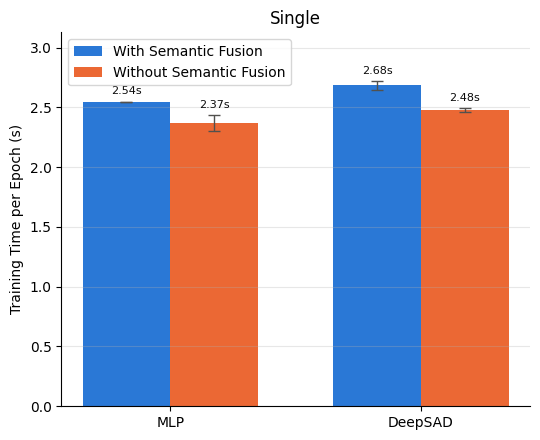

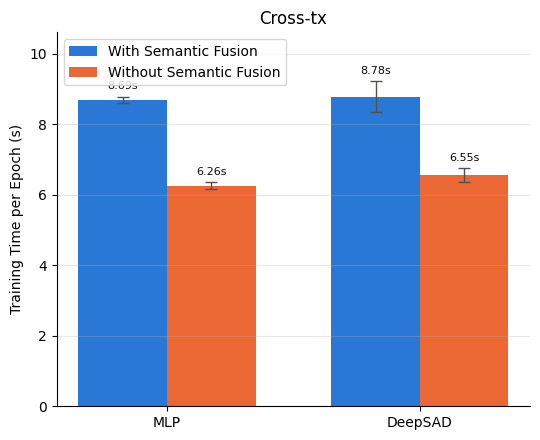

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# One standalone figure per scope; within each, one group per architecture,
# two bars per group (with / without semantic fusion). Each figure scales its
# own y-axis independently.
arch_order = ["MLP", "DeepSAD"]
eval_order = ["With Semantic Fusion", "Without Semantic Fusion"]
COLOR_MAP = {
    "With Semantic Fusion": "#2a78d6",
    "Without Semantic Fusion": "#eb6834",
}

x = np.arange(len(arch_order))
bar_width = 0.35

def plot_epoch_time_for_scope(scope: str):
    scope_df = foldtime_df[foldtime_df["scope"] == scope]
    y_max = (scope_df["epoch_time_mean"] + scope_df["epoch_time_std"]).max() * 1.15

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    for i, ev in enumerate(eval_order):
        sub = scope_df[scope_df["evaluation"] == ev].set_index("arch").reindex(arch_order)
        means = sub["epoch_time_mean"].to_numpy()
        stds = sub["epoch_time_std"].to_numpy()
        offset = (i - 0.5) * bar_width
        ax.bar(
            x + offset, means, bar_width,
            yerr=stds, capsize=4,
            color=COLOR_MAP[ev], label=ev,
            error_kw={"elinewidth": 1, "ecolor": "#52514e"},
        )
        for xi, mean, std in zip(x + offset, means, stds):
            ax.annotate(
                f"{mean:.2f}s",
                (xi, mean + std),
                textcoords="offset points",
                xytext=(0, 4),
                ha="center",
                va="bottom",
                fontsize=8,
                color="#0b0b0b",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(arch_order)
    ax.set_title(scope)
    ax.set_ylabel("Training Time per Epoch (s)")
    ax.set_ylim(0, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_epoch_time_for_scope("Single")
plot_epoch_time_for_scope("Cross-tx")

In [7]:
def format_stat(mean, std):
    return f"{mean:.2f} ± {std:.2f}"

rows = []
for arch, scope, _ in MODEL_GROUPS:
    with_row = foldtime_df[
        (foldtime_df["arch"] == arch)
        & (foldtime_df["scope"] == scope)
        & (foldtime_df["evaluation"] == "With Semantic Fusion")
    ].iloc[0]
    without_row = foldtime_df[
        (foldtime_df["arch"] == arch)
        & (foldtime_df["scope"] == scope)
        & (foldtime_df["evaluation"] == "Without Semantic Fusion")
    ].iloc[0]
    pct_reduction = 1 - (without_row["epoch_time_mean"] / with_row["epoch_time_mean"])
    rows.append({
        "Model": arch,
        "Scope": scope,
        "With Semantic Fusion (s/epoch)": format_stat(with_row["epoch_time_mean"], with_row["epoch_time_std"]),
        "Without Semantic Fusion (s/epoch)": format_stat(without_row["epoch_time_mean"], without_row["epoch_time_std"]),
        "Reduction (%)": pct_reduction * 100,
    })

epoch_time_table_df = pd.DataFrame(rows)
epoch_time_table_df

,Model,Scope,With Semantic Fusion (s/epoch),Without Semantic Fusion (s/epoch),Reduction (%)
0,MLP,Single,2.54 ± 0.00,2.37 ± 0.07,6.926675
1,MLP,Cross-tx,8.69 ± 0.08,6.26 ± 0.10,27.979667
2,DeepSAD,Single,2.68 ± 0.04,2.48 ± 0.02,7.691459
3,DeepSAD,Cross-tx,8.78 ± 0.44,6.55 ± 0.20,25.369720


In [8]:
# Turn the unicode ± into LaTeX math syntax and format the reduction as a percentage
import re

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) ± (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = epoch_time_table_df.copy()
latex_ready["With Semantic Fusion (s/epoch)"] = latex_ready["With Semantic Fusion (s/epoch)"].map(to_math_pm)
latex_ready["Without Semantic Fusion (s/epoch)"] = latex_ready["Without Semantic Fusion (s/epoch)"].map(to_math_pm)
latex_ready["Reduction (%)"] = latex_ready["Reduction (%)"].map(lambda v: f"{v:.1f}\\%")

latex_str = latex_ready.to_latex(
    index=False,
    escape=False,  # cell values already contain LaTeX ($\pm$, \%), don't double-escape
    column_format="ll" + "c" * (len(latex_ready.columns) - 2),
    caption="Per-epoch training time with and without semantic fusion",
    label="tab:ablation_semantic_fusion_epoch_time",
)
print(latex_str)

\begin{table}
\caption{Per-epoch training time with and without semantic fusion}
\label{tab:ablation_semantic_fusion_epoch_time}
\begin{tabular}{llccc}
\toprule
Model & Scope & With Semantic Fusion (s/epoch) & Without Semantic Fusion (s/epoch) & Reduction (%) \\
\midrule
MLP & Single & $2.54 \pm 0.00$ & $2.37 \pm 0.07$ & 6.9\% \\
MLP & Cross-tx & $8.69 \pm 0.08$ & $6.26 \pm 0.10$ & 28.0\% \\
DeepSAD & Single & $2.68 \pm 0.04$ & $2.48 \pm 0.02$ & 7.7\% \\
DeepSAD & Cross-tx & $8.78 \pm 0.44$ & $6.55 \pm 0.20$ & 25.4\% \\
\bottomrule
\end{tabular}
\end{table}

